# Modelo de reator CSTR com balanço de energia


## Apresentação

Nesse notebook, o problema apresentado é um CSTR com balanço de energia. Esse exemplo ilustra que o reator CSTR pode ter comportamento dinâmico não linear. Com ele, simulamos o efeito de uma mudança gradual na temperatura do fluido refrigerante $T_c$ nas direções positiva e negativa.

As variáveis de estados (as variáveis que integramos) são a concentração de A ($C_A$) e a temperatura do reator $T$. A variável manipulada é a temperatura da água da camisa $T_c$.

## Problema Proposto

Esse problema é o Exemplo 2.5 do livro do autor Seborg. No presente problema, temos um reator do tipo CSTR não isotérmico. Na imagem a seguir, vemos a ilustração desse reator.

<center><img src="https://github.com/amandalemette/ENG1818/blob/5c05cba96e599eb97a649f673a3a9d88e844d104/Imagens/im11.png?raw=true"  width=400 height=320 />

Assumimos que a cinética é dominada por uma única reação de primeira ordem e irreversível

$$
A \ \xrightarrow{{k_{C_A}}} \ B
$$

A taxa de reação por unidade de volume é modelada como sendo o produto $k\cdot C_A$ onde $C_A$ é a concentração de A. A constante reacional $k(T)$ aumenta com a temperatura seguindo a lei de Arrhenius:

$$
k(t) = k_0e^{-\frac{Ea}{RT}}
$$

- $Ea$: energia de ativação
- $T$: temperatura
- $R$: constante dos gases ideais
- $k_0$: fator pré-exponencial

| | Variable | &nbsp; &nbsp; &nbsp; &nbsp; Symbol &nbsp; &nbsp; &nbsp; &nbsp;  |&nbsp; &nbsp; Value &nbsp; &nbsp; | &nbsp; &nbsp; Units &nbsp; &nbsp;|
|---:| :-: | :-: | :-: | :-: |
|1| Energia ativ./Cte gases | $\frac{Ea}{R}$ | 8750| $K$|
|2| Fator pré-exponencial | $k_0$ | $7.2\cdot 10^{10}$ | $\frac{1}{min}$|
|3| Volume do reator | $V$ | $100$ | $L$|
|4| Densidade | $\rho$ | $1000$ | $g/L$|
|5| Capacidade calorífica | $C_p$ | $0.239$ | $J/g/K$|
|6| Entalpia de reação | $\Delta H_R$ | $-50000$ | $J/mol$|
|7| Vazão de alimentação| $q$ | $100$ | $L/min$|
|8| Concentração de alimentação | $C_{Ai}$ | $1.0$ | $mol/L$|
|9| Temperatura de alimentação | $T_i$ | $350$ | $K$|
|10| Concentração inicial | $C_{A0}$ | $0.5$ | $mol/L$|
|11| Temperatura inicial | $T_0$ | $350$ | $K$|
|12| Temperatura de resfriamento | $T_c$ | $300$ | $K$|
|13| Coeficiente de troca de calor * área de troca térmica | $UA$ | $50000$ | $J/min/K$|

obs: $U$ é o coeficiente global de troca térmica e $A$ é a área de troca térmica e ambos são considerados constantes.

- Modelo:

$$
V\frac{dC_A}{dt} = q(C_{Ai}-C_A) - VkC_A
$$

$$
V\rho C_p\frac{dT}{dt} = wC_p(T_i - T) + (-\Delta H_R)VkC_A + UA(T_c-T)
$$

Normalizando as equações para isolarmos $C_A$ e $T$, temos:

$$
\frac{dC_A}{dt} = \frac{q}{V}(C_{Ai}-C_A) - kC_A
$$

$$
\frac{dT}{dt} = \frac{w}{V\rho}(T_i - T) + \frac{(-\Delta H_R)}{\rho C_p}kC_A + \frac{UA}{V\rho C_p}(T_c-T)
$$

Substituindo $w/\rho$ por $q$, temos:

$$
\frac{dC_A}{dt} = \frac{q}{V}(C_{Ai}-C_A) - kC_A
$$

$$
\frac{dT}{dt} = \frac{q}{V}(T_i - T) + \frac{(-\Delta H_R)}{\rho C_p}kC_A + \frac{UA}{V\rho C_p}(T_c-T)
$$

## Atividades:

### Atividade 1

Faça um gráfico da constante reacional $k(T)$ em função da temperatura em $^oC$. Salve o gráfico em uma figura de resolução 600 dpi.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [ ]:
k0 = 7.2e10 # 1/min
Ea_R = 8750 # K

In [ ]:
k_eq = lambda Temp: k0*np.exp(-Ea_R/Temp)

In [ ]:
temp = np.linspace(300, 1000)
kk = k_eq(temp)

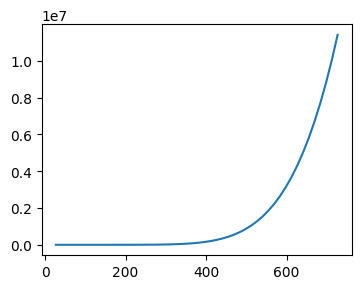

In [ ]:
fig = plt.figure(figsize=(4,3))
plt.plot(temp-273.15,kk)
plt.show()

### Atividade 2

Implemente o modelo de CSTR com balanço de energia e simule o mesmo considerando as considerando condições iniciais e os parâmetros mostrados na tabela.

Gere dois plots:

1. concentração de $A$ em função do tempo de reação em $min$.
2. temperatura do reator (em $^oC$) em função do tempo de reação em $min$.


In [ ]:
# Parametros
k0 = 7.2e10         # 1/min
Ea_R = 8750         # K
q = 100             # L/min
CAi = 1             # mol/L
V = 100             # L
Ti = 350            # K
deltaHr = -50_000   # J/mol
rho = 1000          # g/L
Cp = 0.239          # J/g/K
UA = 50_000         # J/min/K
Tc = 300            # K
CA0 = 0.5           # mol/L
T0 = 350            # K

$$
\frac{dC_A}{dt} = \frac{q}{V}(C_{Ai}-C_A) - kC_A
$$

$$
\frac{dT}{dt} = \frac{q}{V}(T_i - T) + \frac{(-\Delta H_R)}{\rho C_p}kC_A + \frac{UA}{V\rho C_p}(T_c-T)
$$

In [ ]:
# condicao inicial
CI = [CA0, T0]

# tempo
tempo = np.linspace(0,10)

# funcao que retorna o sistema de EDOs
def fun(y,t):
  CA, T = y[0], y[1]
  k = k_eq(T)
  dydt = np.zeros(len(y))
  dydt[0] = q/V*(CAi - CA) - k*CA # dCAdt
  termo1 = q/V*(Ti - T)
  termo2 = (-deltaHr)/(rho*Cp)*k*CA
  termo3 = UA/(V*rho*Cp)*(Tc - T)
  dydt[1] = termo1 + termo2  + termo3  # dTdt
  #print(t,termo1,termo2,termo3,dydt[0],dydt[1])
  #input()
  return dydt

# simular o reator em operacao
output = odeint(fun, CI, tempo)
CA , T = output[:,0], output[:,1]

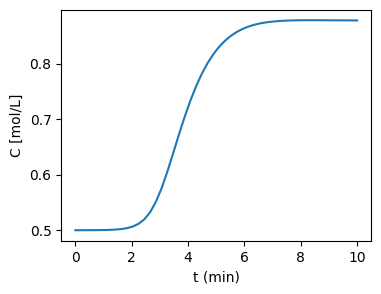

In [ ]:
# plotando os resultados
fig = plt.figure(figsize = (4,3))
plt.plot(tempo,CA)
plt.xlabel('t (min)')
plt.ylabel('C [mol/L]')
plt.show()

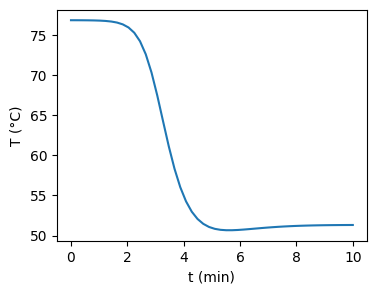

In [ ]:
# plotando os resultados
fig = plt.figure(figsize = (4,3))
plt.plot(tempo,T-273.15)
plt.xlabel('t (min)')
plt.ylabel('T (°C)')
plt.show()

### Atividade 3

Na simulação anterior, você considerou que a temperatura do líquido resfriante era $300 K$. Refaça as simulações, considerando $T_c$ igual a:

- $T_c = 290 K$

e, depois,

- $T_c = 305 K$

Gere 2 gráficos:

- **Gráfico 1:** Concentração de $A$ em função do tempo com 3 séries ($C_A$ simulada com cada valor de $T_c$ testado: 290, 300 e 305 K)
- **Gráfico 2:** Temperatura do reator ($^oC$) em função do tempo com 3 séries ($T$ simulada com cada valor de $T_c$ testado: 290, 300 e 305 K)

Analise os gráficos.

## Discussão

 completar

## Referências

- Fogler, Scott. Elementos de Engenharia das Reações Químicas. LTC, 4a Edição, 2009.
<center><img src="https://github.com/amandalemette/ENG1818/blob/601183f3155bf66274ffa37137c158cc0ac5d975/Imagens/im10.png?raw=true"  width=100 height=160 />

- Seborg, Edgar, Mellichamp, Doyle. Process Dynamics and Control. John Wiley & Sons, Inc., 3rd Edition, 2011.
<center><img src="https://github.com/amandalemette/ENG1818/blob/78e5c648d72e43bd37e12997312be0925fc05518/Imagens/im12.png?raw=true"  width=100 height=160 />
